In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_PATH = Path("../data/raw/cbtweets/CBTweets.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (47692, 2)


In [3]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
for column in df.columns:
    print("-", column)

Number of rows: 47692
Number of columns: 2

Columns:
- tweet_text
- cyberbullying_type


In [4]:
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [6]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Total missing values: 0


In [7]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 36


In [8]:
class_counts = df["cyberbullying_type"].value_counts()

print(class_counts)

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


In [9]:
class_percentages = (
    df["cyberbullying_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

cyberbullying_type
religion               16.77
age                    16.76
gender                 16.72
ethnicity              16.69
not_cyberbullying      16.66
other_cyberbullying    16.40
Name: proportion, dtype: float64


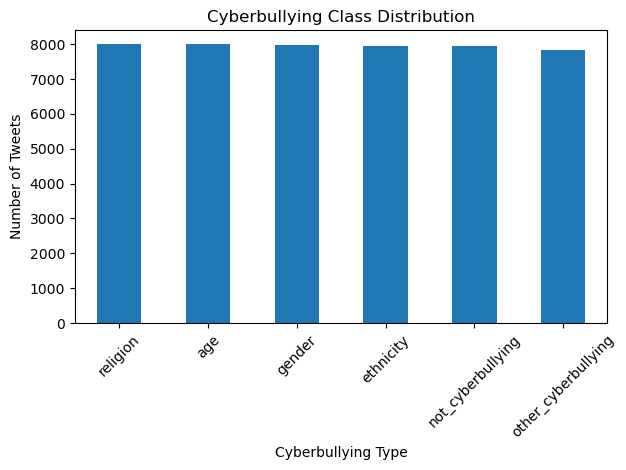

In [10]:
class_counts.plot(kind="bar")

plt.title("Cyberbullying Class Distribution")
plt.xlabel("Cyberbullying Type")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df["text_length"] = df["tweet_text"].str.len()

df["text_length"].describe()

count    47692.000000
mean       136.253229
std         85.226899
min          1.000000
25%         78.000000
50%        124.000000
75%        180.000000
max       5018.000000
Name: text_length, dtype: float64

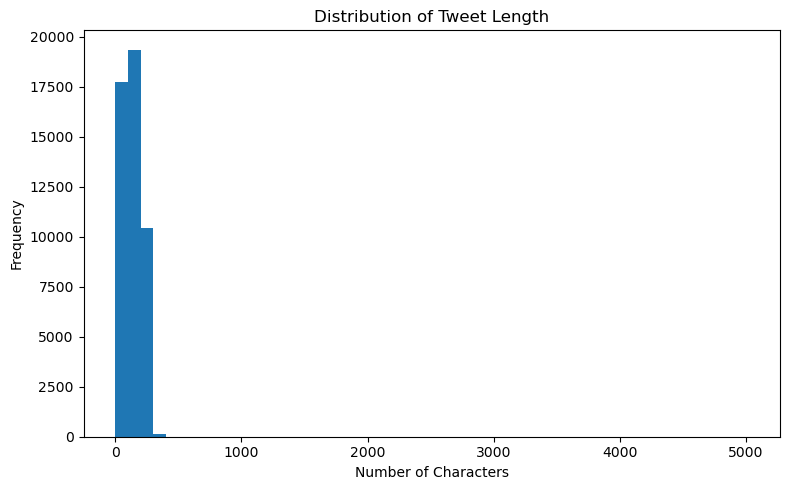

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Tweet Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
long_texts = df[df["text_length"] > 500]

print("Tweets longer than 500 characters:", len(long_texts))

long_texts[["tweet_text", "cyberbullying_type", "text_length"]].head(10)

Tweets longer than 500 characters: 23


,tweet_text,cyberbullying_type,text_length
1317,@EurekAlertAAAS: Researchers push to import to...,not_cyberbullying,1809
3030,He embellished the afternoon with moustachioed...,not_cyberbullying,1056
4846,@andrea_gcav: @viviaanajim recuerdas como noso...,not_cyberbullying,845
10140,"Why boys crack up at rape jokes, think having ...",gender,572
10922,don't make rape jokes!!! don't make gay jokes!...,gender,1431
14168,IT CALLS THE FUNCTION TO THE PROCESS OR IT GE…...,gender,1116
15621,"@ufcpride40: : Terry Bean, prominent gay activ...",gender,1270
18157,https://www-dailymail-co-uk.cdn.ampproject.org...,religion,568
21241,And yet God was able to meet their needs using...,religion,529
23549,RADICAL LEFTIST GROUP Threatens Christian Pray...,religion,509


In [14]:
long_tweets = df[df["text_length"] > 500]

print("Number of long tweets:", len(long_tweets))

for i, row in long_tweets.iterrows():
    print("\n" + "=" * 80)
    print("Label:", row["cyberbullying_type"])
    print("Length:", row["text_length"])
    print("Tweet:")
    print(row["tweet_text"])

Number of long tweets: 23

Label: not_cyberbullying
Length: 1809
Tweet:
@EurekAlertAAAS: Researchers push to import top anti-bullying program to US schools http://t.co/UPZrMbl
@NomCookiesNom Instead of personal attacks, maybe you can explain why there are more than 100 Islamic terrorist groups.
@_Finessinfool yea imma bring in tomorrow
#mkr I think Colin might not be a fan of the meatballs.
@KatieBatterman yeah, we should talk. I was just about to send an email over to them right before I was told it was retracted.
I'm not a fan of the bears from QLD. 💩 #MKR
@eDRoaCH @orvtech this isn't de-anonymizing. the phone # wouldn't necessarily be stored. no names would be required.
@owlcity hey adam :) I've been to 2 of your concerts &amp; haven't been allowed to meet you. when will I be able to?
Me: The boat or the thing that melts Nazi faces?
Watching a video of the snowman play from primary school! Go Tanners Wood haha #oldschool
@eranubuwah @352_7538 Taking tiny villages while loosing major